# 다이캐스팅 공정 데이터 기반 품질 예측 프로젝트

- 다이캐스팅은 용융 금속을 금형에 고압으로 주입하여 정밀한 제품을 생산하는 공정이다.
- 생산 효율을 높이고 불량품을 낮추기 위해 공정 변수 및 센서 데이터를 분석해서 불량 유형을 자동 예측하는 머신러닝 모델을 개발해야함.
- 실시간 공정 데이터와 품질 검사를 연계하여 품질 예측 시스템을 구축하고자 함.

# 비즈니스 문제 정의

### 현재 상황

- 불량품이 발생해도 육안 검사에 의존하여 판정 기준의 주관성과 검사 속도의 한계로 생산성이 저하됨.
- 불량 발생 원인을 추적하기 힘들어 공정 개선 및 문제 해결이 어려움.
- 공정 데이터와 품질 검사를 효과적으로 매핑하지 못하여 실시간 품질 관리 및 재발 방지 대책이 부족한 상황.

### 분석 목표

- 다이캐스팅 공정 과정에서 발생하는 다양한 불량 유형을 자동으로 예측해주는 머신 러닝 모델 개발
- 공정 데이터와 센서 데이터를 면밀히 분석해 불량 여부와의 관계성 파악
- 불량 발생의 주요 원인을 분석해서 공정의 최적화를 지원
- 실시간 품질 예측 체계를 구축하여 조기 경보 시스템 도입 및 불량률 감소

### 비즈니스 산출물

1) 불량 발생의 주요 원인을 분석하고 이를 시각화하여 제시
2) 불량 유형을 자동으로 예측해주는 머신러닝 모델 제시

# 데이터셋 구성

- **공정(Process)데이터**
1) Shot ID : 주조 샷 고유 식별자
2) Injection Speed : 용탕 주입 속도 (m/s)
3) Die Temperature : 금형 온도
4) Casting Pressure : 주조 압력 (bar)
5) Cooling Time: 냉각 시간 (s)

- **센서(Sensor) 데이터**
1) Mold Temp Sensor : 금형 내 센서 온도 (°C)
2) Hydraulic Pressure : 유압 압력 (bar)
3) Vibration Sensor : 진동값 (Hz)
4) Flow Rate Sensor : 유량 (L/min)

- **불량(Defects) 데이터**
1) Defect Type : 발생한 불량 유형 (미성형, 박리, 기공, 평탄, 개재물 등)
2) Defect Status : 양품(0) / 불량(1) 여부

In [1]:
# ============================================================
# 공정(Process) 주요 컬럼 설명
# ============================================================
# • Shot ID                       : 주조 번호 (붕어빵 틀에 반죽을 한 번 붓고 뚜껑을 닫는 행위에 관한 일련번호)
# • Injection Speed               : 주입 속도 (쇳물을 금형에 얼마나 빨리 밀어 넣는가)
# • Die Temperature               : 금형 온도 (금형 틀이 어느정도의 온도인가)
# • Casting Pressure              : 주조 압력 (쇳물을 다 채운 뒤 강하게 누르는 힘)
# • Cooling Time                  : 냉각 시간 (액체 상태인 금속이 고체가 될 떄까지 기다리는 힘)


# ============================================================
# 공정(Process) 컬럼별 분석 관점
# ============================================================
# • Injection Speed               : 주입 속도가 너무 느리면 쇳물이 금형으로 가다가 굳어버리고, 너무 빠르면 사방으로 튀어서 속에 공기 방울(기공)이 생길 수 있다.
# • Die Temperature               : 금형 온도가 너무 낮으면 쇳물이 일찍 굳고 너무 높으면 금형 수명이 줄거나 제품이 달라붙는 현상이 생긴다.
# • Casting Pressure              : 압력이 너무 낮으면 기공이 발생할 수 있고, 너무 높으면 금형 손상 및 제품 변형이 일어날 수 있다.
# • Cooling Time                  : 냉각 시간이 너무 짧으면 탈형 시 변형이 오고, 너무 느리면 사이클 타임이 늘어나 생산성이 떨어진다.


# ============================================================
# 센서(Sensor) 주요 컬럼 설명
# ============================================================
# • Mold Temp Sensor               : 금형 내부 온도 (Die Temperature가 전체의 겉 온도라면, 이거는 틀 안쪽 깊숙한 곳의 실시간 온도이다)
# • Hydraulic Pressure             : 유압 압력 (bar) (쇳물을 밀어내기 위해 기계 팔(실린더)이 쓰는 기름의 힘 혈압과 비슷하다고 볼 수 있음)
# • Vibration Sensor               : 진동값 (Hz) (기계가 작동할 떄의 떨림)
# • Flow Rate Sensor               : 유량 (L/min) (틀을 식히기 위한 냉각수가 흐르는 속도를 나타냄)


# ============================================================
# 센서(Sensor) 컬럼별 분석 관점
# ============================================================
# • Mold Temp Sensor               : 쇳물이 들어올 때 순간 확 올랐다가 식으면서 툭 떨어지는 경향을 보인다
# • Hydraulic Pressure             : 유압 압력은 혈압과 비슷하다고 생각할 수 있다. 유압 압력이 일정해야 쇳물을 쏘아 주는 힘이 균일해진다.
# • Vibration Sensor               : 평소보다 많이 흔들린다면 나사가 풀렸거나, 부품이 마모됐거나, 쇳물이 튀어서 어딘가 걸렸다는 신호일 수 있다.
# • Flow Rate Sensor               : 유량이 적으면 틀이 식지 않아서 제품이 녹아내릴 수 있다.


# ============================================================
# 불량(Defects) 주요 컬럼 설명
# ============================================================
# • Defect Type                   : 발생한 불량 유형
# • Defect Status                 : 양품(0) / 불량(1) 여부


# ============================================================
# 불량(Defects) 유형 설명
# ============================================================
# • 미성형 (Underfill/Short Shot)  : 반죽이 모자라 다 완성되지 못한 붕어빵 (주입 속도가 느리거나, 금형 온도가 낮을 때 주로 발생) -> Injection Speed, Mold Temp Sensor
# • 박리 (Lamination/Peeling)      : 금속 층이 서로 제대로 붙지 않고 겹쳐진 상태 (쇳물이 들어갈 때 너무 차갑거나, 불순물이 섞여 층이 생기면 발생) -> Mold Temp Sensor, Flow Rate Sensor
# • 기공 (Porosity/Gas Hole)       : 공기 방울이 송송 뚫린 상태(주조 압력이 너무 낮거나, 주입 속도가 너무 빨라서 공기가 들어갔을 때 생김) -> Casting Pressure, Injection Speed
# • 평탄 (Flatness Error)          : 바닥이 평평하지 않고 휘어진 붕어빵 (냉각 시간이 너무 짧거나, 냉각수가 골고루 잘 흐르지 못했을 때 발생) -> Cooling Time, Flow Rate Sensor
# • 개재물 (Inclusion)             : 반죽에 검은 가루나 돌멩이가 들어간 것 (재료 관리가 안되었거나, 필터에 문제가 있을 때 발생) -> Flow Rate Sensor

---
# 1.1 필요 라이브러리 및 폰트 로드

In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)


라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1.2 데이터 로드

In [3]:
# 1. 원본 데이터 로드
df_original = pd.read_csv(r"C:\Users\610ha\Desktop\내배캠\Second_project\data\DieCasting_Quality_Raw_Data.csv", header=[0,1])

# 2. 컬럼명 중 첫번째 행을 기준으로 컬럼 분리
process_cols = [col for col in df_original.columns if col[0] == 'Process']
sensor_cols = [col for col in df_original.columns if col[0] == 'Sensor']
defects_cols = [col for col in df_original.columns if col[0] == 'Defects']

# 3. 첫 번째 컬럼을 기준으로 분리된 데이터 프레임 생성
df_process = df_original[process_cols].copy()
df_sensor = df_original[sensor_cols].copy()
df_defects = df_original[defects_cols].copy()

# 4. 두 번째 행에 있는 컬럼명만 사용하도록 변경
# get_level_values(가져오고 싶은 레벨 인덱스) - level 0: 첫번째 행, level 1: 두번째 행
# 왼쪽 .columns: 컬럼명을 바꾸기 위한 설정
# 오른쪽 .columns: 기존 다중레벨 컬럼 가져오기 → get_level_values(1)로 Level 1만 추출
df_process.columns = df_process.columns.get_level_values(1)
df_sensor.columns = df_sensor.columns.get_level_values(1)
df_defects.columns = df_defects.columns.get_level_values(1)

---

# 2 데이터 전처리 (Data Preprocessing)

### 2.1 중복 데이터 확인

In [4]:
# 1. 전체 행에 대한 중복값 확인 -> 완전히 동일한 행이 있는지 확인하는 용도 -> 없음
print(f"전체 행에 대한 데이터 중복값 : {df_original.duplicated().sum()}건")

# 2. ID 기준으로 중복값 확인 -> 설비 ID 중복 확인용 -> 없음
print(f"ID 기준에 대한 중복값 : {df_process.duplicated(subset=["id"]).sum()}건")


전체 행에 대한 데이터 중복값 : 0건
ID 기준에 대한 중복값 : 0건


### 2.2 데이터 타입 확인

In [24]:
# 각 데이터 프레임별 컬럼의 데이터 형식 확인
print('='*30)
print("<Process 관련 데이터프레임 정보>")
print('='*30)
display(df_process.dtypes)

print('='*30)
print("<Sensor 관련 데이터프레임 정보>")
print('='*30)
display(df_sensor.dtypes)

print('='*30)
print("<Defects 관련 데이터프레임 정보>")
print('='*30)
display(df_defects.dtypes)

<Process 관련 데이터프레임 정보>


id                      int64
product_type            int64
shot                    int64
velocity_1            float64
velocity_2            float64
velocity_3            float64
high_velocity         float64
cylinder_pressure       int64
rapid_rise_time       float64
biscuit_thickness       int64
clamping_force          int64
cycle_time            float64
pressure_rise_time    float64
casting_pressure        int64
spray_time            float64
spray_1_time          float64
spray_2_time          float64
dtype: object

<Sensor 관련 데이터프레임 정보>


melting_furnace_temp    float64
air_pressure            float64
air_pressure_min          int64
air_pressure_max          int64
coolant_temp            float64
coolant_temp_min          int64
coolant_temp_max          int64
coolant_pressure        float64
factory_temp            float64
factory_temp_min        float64
factory_temp_max        float64
factory_humidity        float64
factory_humidity_min    float64
factory_humidity_max    float64
dtype: object

<Defects 관련 데이터프레임 정보>


short_shot_1       int64
bubble_1           int64
exfoliation_1      int64
blow_hole_1        int64
stain_1            int64
dent_1             int64
deformation_1      int64
contamination_1    int64
impurity_1         int64
crack_1            int64
scratch_1          int64
buring_mark_1      int64
inclusions_1       int64
short_shot_2       int64
bubble_2           int64
exfoliation_2      int64
blow_hole_2        int64
stain_2            int64
dent_2             int64
deformation_2      int64
contamination_2    int64
impurity_2         int64
crack_2            int64
scratch_2          int64
buring_mark_2      int64
inclusions_2       int64
dtype: object

### 2.3 컬럼 정제

In [25]:
# 1. 공백 제거 및 컬럼명 소문자 통일
df_process.columns = df_process.columns.astype("str").str.strip().str.lower()
df_sensor.columns = df_sensor.columns.astype("str").str.strip().str.lower()
df_defects.columns = df_defects.columns.astype("str").str.strip().str.lower()

In [26]:
# 2. Sensor 데이터프레임에서 _min/_max로 끝나는 컬럼 찾아서 삭제
minmax_cols = [c for c in df_sensor.columns if c.endswith("_min") or c.endswith("_max")]
df_sensor_clean = df_sensor.drop(columns=minmax_cols)


print("삭제한 _min/_max 컬럼 수:", len(minmax_cols))
print("삭제 전 df_sensor shape:", df_sensor.shape)
print("삭제 후 df_sensor shape:", df_sensor_clean.shape)

삭제한 _min/_max 컬럼 수: 8
삭제 전 df_sensor shape: (7535, 14)
삭제 후 df_sensor shape: (7535, 6)


### 2.4 불량 유형 고유값 처리

In [28]:
# 1. 1(고장)이 아닌 유형의 값이 존재하는 컬럼
target_columns = [
    "short_shot_1", "exfoliation_1", "blow_hole_1", "stain_1", "deformation_1",
    "short_shot_2", "bubble_2", "exfoliation_2", "blow_hole_2", "deformation_2"
]
# 2. 1보다 큰 값을 모두 1로 변환
df_defects[target_columns] = df_defects[target_columns].clip(upper=1)

# 3. 결과 확인 <- 모든 컬럼의 고유값이 [0, 1]로 정리되었는지 확인용
print("<1보다 큰 값은 1로 변환한 후, 고유값 확인>")
for col in df_defects:
    print(f"{col}: {df_defects[col].unique()}")

<1보다 큰 값은 1로 변환한 후, 고유값 확인>
short_shot_1: [0 1]
bubble_1: [0 1]
exfoliation_1: [0 1]
blow_hole_1: [0 1]
stain_1: [0 1]
dent_1: [0 1]
deformation_1: [0 1]
contamination_1: [0 1]
impurity_1: [0 1]
crack_1: [0 1]
scratch_1: [0 1]
buring_mark_1: [0 1]
inclusions_1: [0]
short_shot_2: [0 1]
bubble_2: [0 1]
exfoliation_2: [0 1]
blow_hole_2: [0 1]
stain_2: [0]
dent_2: [0 1]
deformation_2: [0 1]
contamination_2: [0 1]
impurity_2: [0 1]
crack_2: [0 1]
scratch_2: [0]
buring_mark_2: [0]
inclusions_2: [0 1]


In [29]:
# 4. Cavity 1,2 불량 유형 통합
df_defects_clean =df_defects.copy()

# 4-1. cavity 1/2 컬럼 분리
c1 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_1")]].copy()
c2 =df_defects_clean[[c for c in df_defects_clean.columns if c.endswith("_2")]].copy()

# 4-2. 컬럼명 통일: short_shot_1 -> short_shot
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 4-3. 제대로 분리되었는지 확인
print("c1 shape:", c1.shape)
print("c2 shape:", c2.shape)
print("c1, c2 컬럼이 동일한가?", set(c1.columns) == set(c2.columns))

c1 shape: (7535, 13)
c2 shape: (7535, 13)
c1, c2 컬럼이 동일한가? True


In [31]:
# 4-4. OR 방식으로 통합: 둘 중 하나라도 1이 있다면 1이 입력됨
defects_merged = ((c1 + c2) > 0).astype(int)   # (c1 | c2) 도 가능
df_defects_clean = defects_merged

print("통합 전 df_defects shape:",df_defects.shape)
print("통합 후 df_defects_clean shape:",df_defects_clean.shape)
print("값 종류:", np.unique(df_defects_clean.to_numpy()))
df_defects_clean.head(10)

통합 전 df_defects shape: (7535, 26)
통합 후 df_defects_clean shape: (7535, 13)
값 종류: [0 1]


,short_shot,bubble,exfoliation,blow_hole,stain,dent,deformation,contamination,impurity,crack,scratch,buring_mark,inclusions
0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,1,0,0,0,0,0,0


In [35]:
# 4-5. 전체 셀 기준(모든 defect 칸을 다 펼쳐서 0/1/2 비율)
flat = df_defects_clean.to_numpy().ravel()
dist_all = pd.Series(flat).value_counts(normalize=True).reindex([0,1,2], fill_value=0)
print("<전체 셀 기준 0/1/2 비율>")
print((dist_all * 100).round(2).astype(str) + "%")

<전체 셀 기준 0/1/2 비율>
0    98.16%
1     1.84%
2      0.0%
Name: proportion, dtype: object


### 2.5 불량 유형 분리
- 표면 불량(surface_defect) : 육안으로 확인 가능하지만, 금속의 분리나 갈라짐은 없는 불량        
    - stain(얼룩), dent(찍힘), scratch, burning_mark(소착)

- 구조 불량(structural_defect): 육안으로 금속의 분리·갈라짐이 보이거나, 제품의 강도·기능에 직접 영향을 줄 수 있는 불량 
    - short_shot(미성형), bubble(기포), blow_hole(기공), deformation(변형), crack(균열), exfoliation(박리)

- 이물질 포함 불량(contamination_defect): 원래 포함되면 안 되는 외부 물질이 들어간 불량
    - contamination(오염), impurity(이물), inclusions(개재물)

In [54]:
# 불량 유형 범주화
# 같은 유형의 불량으로 구분된 불량유형이 하나의 shot에 동시에 존재하더라도 1로 처리됨
df_defects_groups = pd.DataFrame(index=df_defects_clean.index)

df_defects_groups["surface_defect"] = ( # 표면과 관련된 불량
    df_defects_clean.reindex(columns=["stain", "dent", "scratch", "burning_Mark"], fill_value=0).max(axis=1)
)

df_defects_groups["structural_defect"] = ( # 구조와 관련된 불량
    df_defects_clean.reindex(columns=["short_shot", "bubble", "blow_hole", "deformation", "crack", "exfoliation"], fill_value=0).max(axis=1)
)

df_defects_groups["contamination_defect"] = ( # 이물질이 포함된 불량
    df_defects_clean
    .reindex(columns=["contamination", "impurity", "inclusions"], fill_value=0)
    .max(axis=1)
)


print("df_defects_groups shape:", df_defects_groups.shape)
print('='*30)
print("고유값 종류:", np.unique(df_defects_groups.to_numpy()))
print('='*30)
print("<각 유형별 불량 개수>")
display(df_defects_groups.sum().sort_values(ascending=False)) # 각 유형별 불량 개수
print('='*30)
df_defects_groups.info() # Non-Null인 행의 개수 확인

df_defects_groups shape: (7535, 3)
고유값 종류: [0 1]
<각 유형별 불량 개수>


structural_defect       1513
surface_defect           202
contamination_defect      19
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   surface_defect        7535 non-null   int64
 1   structural_defect     7535 non-null   int32
 2   contamination_defect  7535 non-null   int32
dtypes: int32(2), int64(1)
memory usage: 117.9 KB


### 2.6 Shot ID 컬럼 통합

In [55]:
# 1. "shot_key" 컬럼 생성
df_process_clean =df_process.copy()
df_process_clean["shot_key"] =df_process_clean["id"].astype(str) + "_" + df_process_clean["shot"].astype(str)

# 2. id, Shot 컬럼 삭제
df_process_clean =df_process_clean.drop(columns=["id", "shot"])

# 3. "shot_key" 컬럼을 맨 앞으로 이동
cols = ["shot_key"] + [c for c in df_process_clean.columns if c != "shot_key"]
df_process_clean =df_process_clean[cols]

# 4. "shot_key"가 중복인 값이 있는지 확인
dup =df_process_clean["shot_key"][df_process_clean["shot_key"].duplicated(keep=False)]
print("중복인 값의 개수:", dup.shape[0])

중복인 값의 개수: 0


In [56]:
# 5. "product_type"의 고유값 및 개수 확인 --> 제품 유형별로 분석을 진행하기 위해서
print(df_process["product_type"].value_counts())

product_type
1    4207
2    3328
Name: count, dtype: int64


In [62]:
# 6. shot_key 컬럼이 추가된 전체 데이터프레임 제작
df_clean = pd.concat([df_process_clean, df_sensor_clean, df_defects_groups], axis=1)

print("df_clean shape:", df_clean.shape)
df_clean.head()

df_clean shape: (7535, 25)


,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,surface_defect,structural_defect,contamination_defect
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0,0,0
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,1,0
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0,0,0


### 2.7 결측값 처리

In [65]:
# 1. 데이터프레임 내 결측값 확인
na_count = df_clean.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0].sort_values(ascending=False)

print("<그룹별 결측치(전체 결측값의 개수)>")
print(pd.Series({
    "Process": df_process_clean.isna().sum().sum(),
    "Sensor":  df_sensor_clean.isna().sum().sum(),
    "Defects": df_defects_clean.isna().sum().sum()
}))
print()

print('='*30)
print("<결측치가 있는 컬럼 및 결측값의 수>")
print(na_cols.sort_values(ascending=False))
print()

<그룹별 결측치(전체 결측값의 개수)>
Process      0
Sensor     180
Defects      0
dtype: int64

<결측치가 있는 컬럼 및 결측값의 수>
factory_humidity    90
factory_temp        90
dtype: int64



In [70]:
# 2. 결측치가 존재하는 데이터프레임 행 확인
nan_rows = df_sensor_clean[df_sensor_clean.isna().any(axis=1)]
display(nan_rows.head(10))

,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity
6913,659.5,6.8,27.4,2.62,NaN,NaN
6914,659.5,6.8,27.4,2.62,NaN,NaN
6915,659.5,6.8,27.4,2.62,NaN,NaN
6916,659.5,6.8,27.4,2.62,NaN,NaN
6917,660.1,6.9,27.4,2.64,NaN,NaN
6918,660.1,6.9,27.4,2.64,NaN,NaN
6919,660.8,6.9,27.4,2.63,NaN,NaN
6920,660.8,6.9,27.4,2.63,NaN,NaN
6921,660.8,6.9,27.4,2.63,NaN,NaN
6922,660.8,6.9,27.4,2.63,NaN,NaN


### 2.7.1 선형 보간법으로 공장의 온도, 습도 결측치를 채우기 전의 그래프

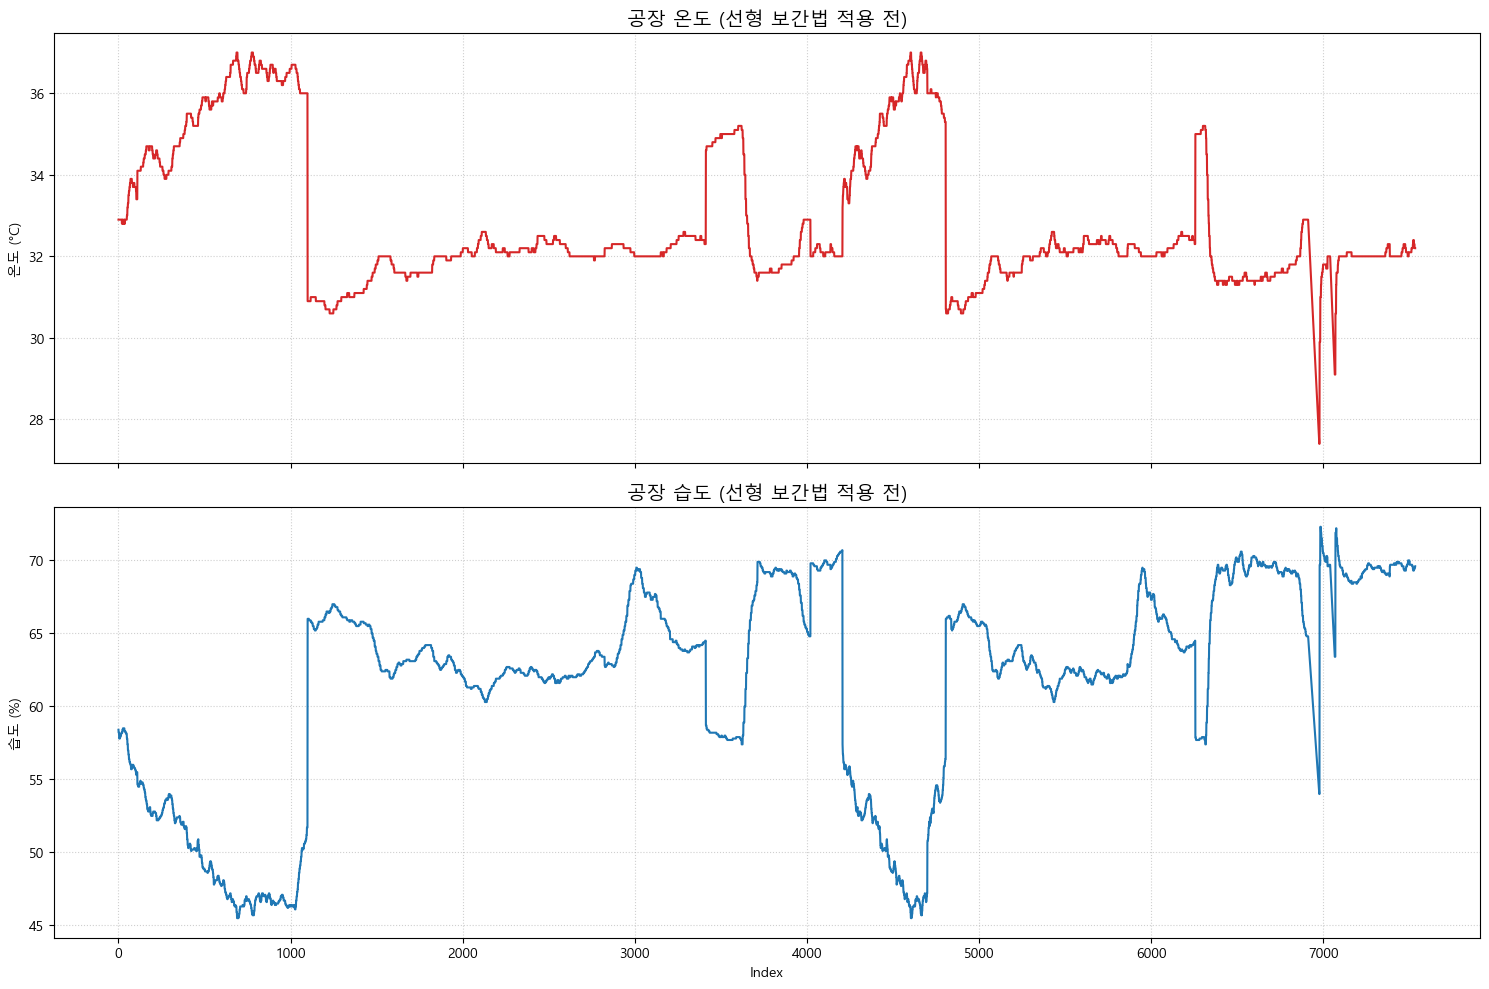

In [80]:
# 1. 공장 온도 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(df_sensor_clean.index, df_sensor_clean['factory_temp'], color='tab:red', linewidth=1.5)
ax1.set_title('공장 온도 (선형 보간법 적용 전)', fontsize=14)
ax1.set_ylabel('온도 (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. 공장 습도 시각화
ax2.plot(df_sensor_clean.index, df_sensor_clean['factory_humidity'], color='tab:blue', linewidth=1.5)
ax2.set_title('공장 습도 (선형 보간법 적용 전)', fontsize=14)
ax2.set_ylabel('습도 (%)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Index')
plt.tight_layout()
plt.show()

### 2.7.2. 선형보간법으로 결측치 대체

In [ ]:
# 1. 선형 보간법으로 결측치 채우기
df_sensor_clean['factory_temp'] = df_sensor_clean['factory_temp'].interpolate(method='linear', limit_direction='both')
df_sensor_clean['factory_humidity'] = df_sensor_clean['factory_humidity'].interpolate(method='linear', limit_direction='both')

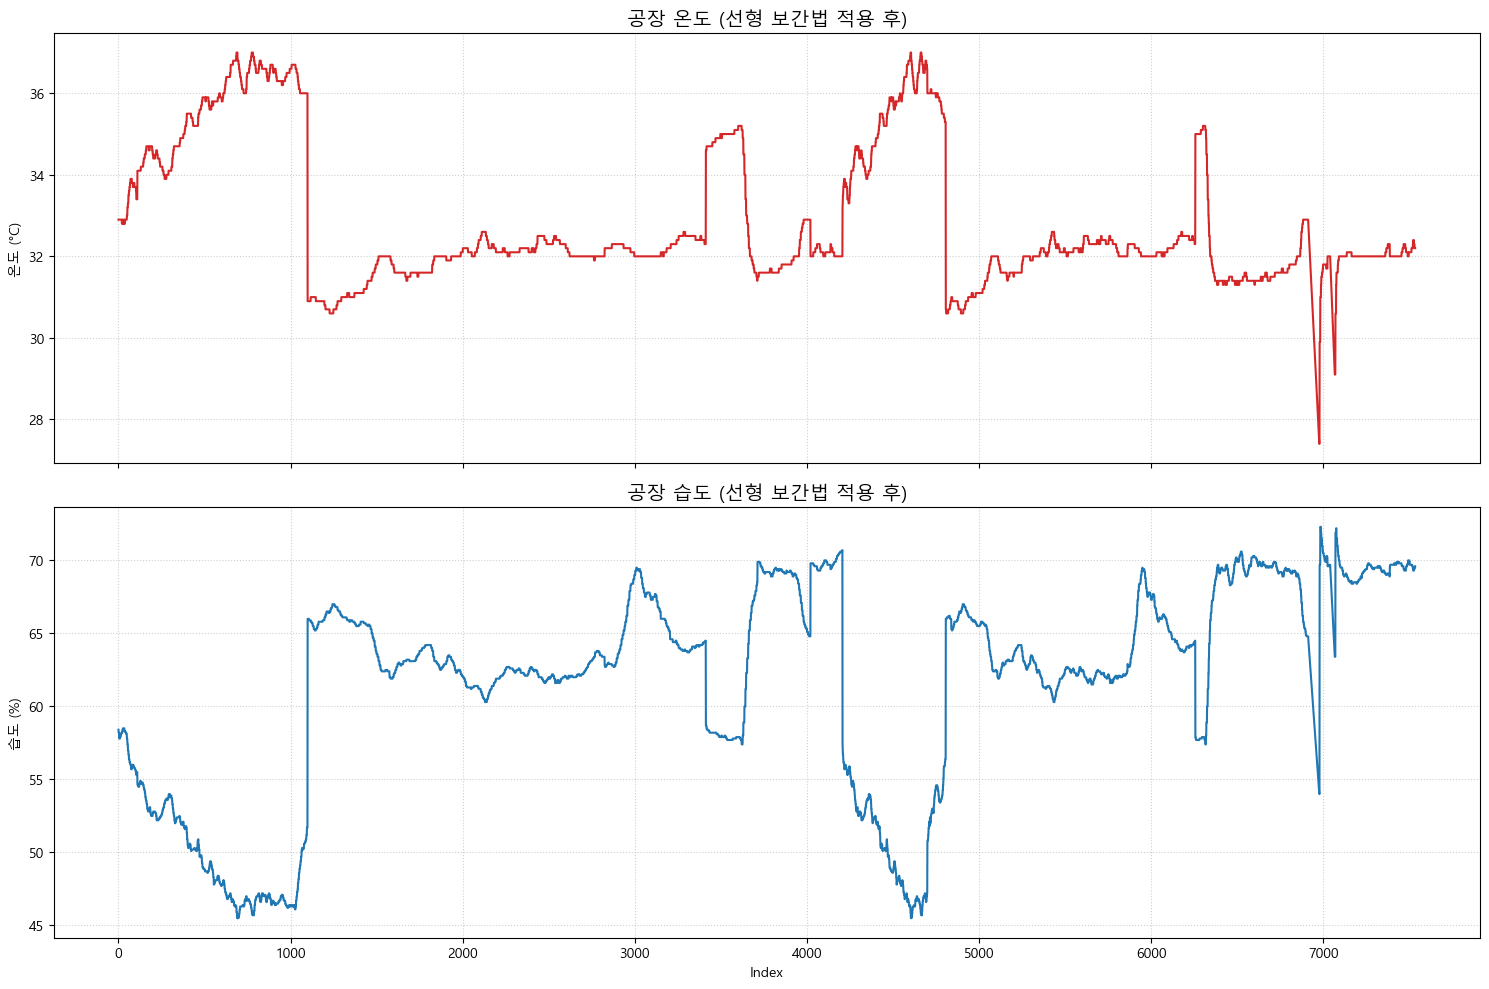

In [ ]:
# 2. 공장 온도 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(df_sensor_clean.index, df_sensor_clean['factory_temp'], color='tab:red', linewidth=1.5)
ax1.set_title('공장 온도 (선형 보간법 적용 후)', fontsize=14)
ax1.set_ylabel('온도 (°C)')
ax1.grid(True, linestyle=':', alpha=0.6)

# 3. 공장 습도 시각화
ax2.plot(df_sensor_clean.index, df_sensor_clean['factory_humidity'], color='tab:blue', linewidth=1.5)
ax2.set_title('공장 습도 (선형 보간법 적용 후)', fontsize=14)
ax2.set_ylabel('습도 (%)')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('Index')
plt.tight_layout()
plt.show()

### 2.8 머신러닝용 데이터셋 저장 (.csv)

In [79]:
df_clean.to_csv("../common-file/for_ML_overall.csv")
df_process_clean.to_csv("../common-file/for_ML_process_data.csv")
df_sensor_clean.to_csv("../common-file/for_ML_sensor_data.csv")
df_defects_clean.to_csv("../common-file/for_ML_defects_data.csv")

### 2.9 이상치 처리

In [83]:
# 1. Process, Sensor 관련 데이터의 기초통계량 확인
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"⬇️{df_name} 관련 데이터의 기초통계량⬇️")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    
    # 1-3. 고유값의 개수, 왜도, 첨도 추가
    stats_df['Unique'] = df_copied.nunique()
    stats_df['Skewness'] = df_copied.skew()
    stats_df['Kurtosis'] = df_copied.kurtosis()
    
    # 1-4. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수', # 결측치가 아닌 값의 개수
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Unique': '고유값',
        'Skewness': '왜도',
        'Kurtosis': '첨도'
    }, inplace=True)
    
    display(stats_df)
    
    return stats_df

In [84]:
# 2. 함수 실행
stats_df_process = create_statistics_summary(df_process_clean, 'Process', exclude_cols=['product_Type'])
stats_df_sensor = create_statistics_summary(df_sensor_clean, 'Sensor')


⬇️Process 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
product_type,7535.0,1.441672,0.496619,1.000,1.000,1.000,2.000,2.000,2,0.234962,-1.945309
velocity_1,7535.0,0.148219,0.007134,0.134,0.142,0.144,0.156,0.180,33,0.638906,-0.689695
velocity_2,7535.0,0.168801,0.004720,0.158,0.166,0.168,0.170,0.212,27,4.08767,28.913573
velocity_3,7535.0,0.191193,0.011563,0.172,0.181,0.188,0.202,0.234,45,0.280346,-1.105678
high_velocity,7535.0,2.319210,0.222041,0.000,2.134,2.161,2.523,2.744,319,-0.347531,5.037868
cylinder_pressure,7535.0,239.655607,23.305451,107.000,217.000,239.000,265.000,266.000,22,-0.017856,-1.370291
rapid_rise_time,7535.0,0.009596,0.002148,0.000,0.008,0.009,0.012,0.021,18,0.332233,-0.359274
biscuit_thickness,7535.0,14.309622,3.286284,0.000,11.000,13.000,17.000,24.000,24,-0.01247,-0.446597
clamping_force,7535.0,306.433311,57.274965,238.000,255.000,258.000,372.000,388.000,42,0.272316,-1.872108
cycle_time,7535.0,27.735979,8.716156,20.200,20.900,22.600,35.900,218.600,61,5.316293,92.781942



⬇️Sensor 관련 데이터의 기초통계량⬇️



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,고유값,왜도,첨도
melting_furnace_temp,7535.0,680.652661,25.288666,635.30,656.70,680.30,703.10,730.00,737,0.124036,-1.284874
air_pressure,7535.0,6.109595,0.647906,4.60,5.70,6.20,6.60,7.10,26,-0.480152,-0.673609
coolant_temp,7535.0,26.830126,0.525149,25.90,26.50,26.80,27.20,28.10,23,0.486100,-0.272945
coolant_pressure,7535.0,2.701155,0.052408,2.58,2.64,2.72,2.74,2.79,22,-0.571114,-1.100549
factory_temp,7535.0,32.799058,1.694920,27.40,31.80,32.10,33.70,37.00,156,1.030967,0.057630
factory_humidity,7535.0,61.670524,7.004554,45.50,58.00,63.00,66.75,72.30,299,-0.872787,-0.275026


### 2.9.1 플래깅 --- 회의 필요

In [86]:
# 1. 함수 정의
def flag_outliers_iqr(df):
    """IQR 방식 플래깅, 전체 데이터 프레임에 적용"""
    
    df_flagged = df.copy()
    
    numeric_cols = df.select_dtypes(include=["number"]).columns # 숫자형 컬럼만 선택
    
    for column in numeric_cols:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
    
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        # 1-1. 플래깅 컬럼 추가(이상치라면 1, IQR 범위 내에 속한다면 0)
        df_flagged[f'{column}_outlier_flag'] = (
            (df[column] < lower_bound) | (df[column] > upper_bound) # OR연산으로 조건 추가
        ).astype(int) # True, False가 1/0으로 출력
    
    return df_flagged

In [91]:
# 2. 함수 실행
df_process_flagged = flag_outliers_iqr(df_process_clean)
df_sensor_flagged = flag_outliers_iqr(df_sensor_clean)

print('='*30)
print("<Process 관련 변수의 데이터프레임(컬럼추가)>")
print('='*30)
display(df_process_flagged.head(10))

print('='*30)
print("<Sensor 관련 변수의 데이터프레임(컬럼추가)>")
print('='*30)
display(df_sensor_flagged.head(10))

<Process 관련 변수의 데이터프레임(컬럼추가)>


,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,product_type_outlier_flag,velocity_1_outlier_flag,velocity_2_outlier_flag,velocity_3_outlier_flag,high_velocity_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,clamping_force_outlier_flag,cycle_time_outlier_flag,pressure_rise_time_outlier_flag,casting_pressure_outlier_flag,spray_time_outlier_flag,spray_1_time_outlier_flag,spray_2_time_outlier_flag
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,5006_6,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,6008_8,1,0.141,0.168,0.178,2.159,214,0.008,11,257,20.6,0.042,1036,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,7009_9,1,0.142,0.172,0.176,2.114,217,0.008,12,257,20.7,0.041,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,8010_10,1,0.142,0.172,0.176,2.114,217,0.008,12,257,20.7,0.041,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,9011_11,1,0.144,0.168,0.184,2.145,217,0.008,11,257,20.7,0.042,1051,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<Sensor 관련 변수의 데이터프레임(컬럼추가)>


,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,melting_furnace_temp_outlier_flag,air_pressure_outlier_flag,coolant_temp_outlier_flag,coolant_pressure_outlier_flag,factory_temp_outlier_flag,factory_humidity_outlier_flag
0,695.0,6.3,26.0,2.71,32.9,58.4,0,0,0,0,0,0
1,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0,0,0,0
2,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0,0,0,0
3,696.4,6.3,26.1,2.69,32.9,58.2,0,0,0,0,0,0
4,697.9,6.4,26.1,2.69,32.9,57.8,0,0,0,0,0,0
5,697.9,6.4,26.1,2.69,32.9,57.8,0,0,0,0,0,0
6,699.6,6.4,26.1,2.71,32.9,57.8,0,0,0,0,0,0
7,699.6,6.4,26.1,2.71,32.9,57.8,0,0,0,0,0,0
8,699.6,6.4,26.1,2.71,32.9,57.8,0,0,0,0,0,0
9,701.4,6.5,26.1,2.71,32.9,57.9,0,0,0,0,0,0


### 2.9.2 이상치가 존재하는 컬럼 (IQR 기준)
- 이상치가 1개 이상 존재하는 컬럼 외엔 플래깅 컬럼 삭제

In [96]:
# 1. 이상치가 존재하지 않는 컬럼 삭제(Process 관련 데이터)

cols_to_drop = [
    col for col in df_process_flagged.columns 
    if col.endswith('_outlier_flag') and df_process_flagged[col].sum() == 0
]

df_process_final = df_process_flagged.drop(columns=cols_to_drop)

df_process_final.head(10)

,shot_key,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_2_outlier_flag,velocity_3_outlier_flag,high_velocity_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,pressure_rise_time_outlier_flag
0,1_1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
1,1002_2,1,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
2,2003_3,1,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
3,3004_4,1,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
4,4005_5,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
5,5006_6,1,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
6,6008_8,1,0.141,0.168,0.178,2.159,214,0.008,11,257,20.6,0.042,1036,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
7,7009_9,1,0.142,0.172,0.176,2.114,217,0.008,12,257,20.7,0.041,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
8,8010_10,1,0.142,0.172,0.176,2.114,217,0.008,12,257,20.7,0.041,1052,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0
9,9011_11,1,0.144,0.168,0.184,2.145,217,0.008,11,257,20.7,0.042,1051,7.8,0.7,0.8,0,0,0,0,0,0,0,0,0


In [ ]:
# 1-1. 이상치가 존재하는 컬럼 삭제 확인
print(f"삭제된 플래그 컬럼 수: {len(cols_to_drop)}개")
print(f"남은 플래그 컬럼(이상치가 존재하는 컬럼): {[c for c in df_process_final.columns if '_outlier_flag' in c]}")

삭제된 플래그 컬럼 수: 6개
남은 플래그 컬럼(이상치가 존재하는 컬럼): ['velocity_1_outlier_flag', 'velocity_2_outlier_flag', 'velocity_3_outlier_flag', 'high_velocity_outlier_flag', 'cylinder_pressure_outlier_flag', 'rapid_rise_time_outlier_flag', 'biscuit_thickness_outlier_flag', 'cycle_time_outlier_flag', 'pressure_rise_time_outlier_flag']


In [ ]:
# 2. 이상치가 존재하지 않는 컬럼 삭제(Sensor 관련 데이터)
cols_to_drop = [
    col for col in df_sensor_flagged.columns 
    if col.endswith('_outlier_flag') and df_sensor_flagged[col].sum() == 0
]

df_sensor_final = df_sensor_flagged.drop(columns=cols_to_drop)

df_sensor_final.head(10)

,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag
0,695.0,6.3,26.0,2.71,32.9,58.4,0
1,696.4,6.3,26.1,2.69,32.9,58.2,0
2,696.4,6.3,26.1,2.69,32.9,58.2,0
3,696.4,6.3,26.1,2.69,32.9,58.2,0
4,697.9,6.4,26.1,2.69,32.9,57.8,0
5,697.9,6.4,26.1,2.69,32.9,57.8,0
6,699.6,6.4,26.1,2.71,32.9,57.8,0
7,699.6,6.4,26.1,2.71,32.9,57.8,0
8,699.6,6.4,26.1,2.71,32.9,57.8,0
9,701.4,6.5,26.1,2.71,32.9,57.9,0


In [99]:
# 2-1. 이상치가 존재하는 컬럼 삭제 확인
print(f"삭제된 플래그 컬럼 수: {len(cols_to_drop)}개")
print(f"남은 플래그 컬럼(이상치가 존재하는 컬럼): {[c for c in df_sensor_final.columns if '_outlier_flag' in c]}")

삭제된 플래그 컬럼 수: 5개
남은 플래그 컬럼(이상치가 존재하는 컬럼): ['factory_temp_outlier_flag']


### 2.9.3 클래핑
- 임계값보다 크거나 작은 값은 각각 상위임계값과 하위임계값으로 대체

In [ ]:
# 1. 함수 정의
def clamp_iqr(df):
    """
    IQR 기준으로 이상치를 클램핑(clip)해서 반환한다. (플래그 없음)
    - 기본 제외 컬럼: ["Product_Type", "shot_key"]
    - k: IQR 배수 (기본 1.5)
    """
    # 1-1. 기본으로 항상 제외할 컬럼
    exclude = ["Product_Type", "shot_key"]

    # 1-2. 숫자 컬럼 중 제외 컬럼 빼기(존재하지 않는 컬럼은 자동으로 무시됨)
    cols = df.select_dtypes("number").columns.difference(exclude)

    # 1-3. IQR 경계 계산
    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    # 1-4. 클램핑 적용 (컬럼별 경계값이므로 axis=1)
    out = df.copy()
    out[cols] = df[cols].clip(lower=low, upper=high, axis=1)

    return out

In [106]:
# 2. 원본에서 클램핑된 값 만들기 (Process 관련 데이터)
df_process_clamped = clamp_iqr(df_process_clean)

# 2-1. 플래그 컬럼만 clamped에 붙이기
flag_cols = df_process_final.filter(like="_outlier_flag").columns
df_process_iqr = pd.concat([df_process_clamped, df_process_final[flag_cols]], axis=1)

In [ ]:
# 2-2. 이상치 개수 확인
display(
    df_process_iqr
    .filter(like="_outlier_flag")
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

velocity_2_outlier_flag            184
biscuit_thickness_outlier_flag      12
cycle_time_outlier_flag             11
high_velocity_outlier_flag          10
rapid_rise_time_outlier_flag        10
velocity_1_outlier_flag              6
velocity_3_outlier_flag              4
cylinder_pressure_outlier_flag       4
pressure_rise_time_outlier_flag      4
dtype: int64

In [ ]:
# 2-3. 실행 결과 확인
df_process_iqr.describe()

,product_type,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,velocity_1_outlier_flag,velocity_2_outlier_flag,velocity_3_outlier_flag,high_velocity_outlier_flag,cylinder_pressure_outlier_flag,rapid_rise_time_outlier_flag,biscuit_thickness_outlier_flag,cycle_time_outlier_flag,pressure_rise_time_outlier_flag
count,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000
mean,1.441672,0.148217,0.168453,0.191193,2.320252,239.675514,0.009595,14.311745,306.433311,27.606729,0.039362,856.944127,9.815979,1.409104,1.396045,0.000796,0.024419,0.000531,0.001327,0.000531,0.001327,0.001593,0.001460,0.000531
std,0.496619,0.007126,0.003083,0.011562,0.215317,23.208356,0.002135,3.277833,57.274965,7.350176,0.003853,234.815490,1.842438,0.557060,0.716170,0.028209,0.154357,0.023036,0.036408,0.023036,0.036408,0.039878,0.038183,0.023036
min,1.000000,0.134000,0.160000,0.172000,1.550500,145.000000,0.002000,2.000000,238.000000,20.200000,0.025500,516.000000,7.000000,0.700000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.142000,0.166000,0.181000,2.134000,217.000000,0.008000,11.000000,255.000000,20.900000,0.036000,596.000000,8.000000,0.800000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.144000,0.168000,0.188000,2.161000,239.000000,0.009000,13.000000,258.000000,22.600000,0.041000,1037.000000,9.700000,1.200000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,0.156000,0.170000,0.202000,2.523000,265.000000,0.012000,17.000000,372.000000,35.900000,0.043000,1053.000000,12.100000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2.000000,0.177000,0.176000,0.233500,2.744000,266.000000,0.018000,24.000000,388.000000,58.400000,0.046000,1164.000000,13.100000,2.500000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [107]:
# 3. 원본에서 클램핑된 값 만들기 (Sensor 관련 데이터)
df_sensor_clamped = clamp_iqr(df_sensor_clean)

# 3-1. 플래그 컬럼만 clamped에 붙이기
flag_cols = df_sensor_final.filter(like="_outlier_flag").columns
df_sensor_iqr = pd.concat([df_sensor_clamped, df_sensor_final[flag_cols]], axis=1)

In [ ]:
# 3-2. 이상치 개수 확인
display(
    df_sensor_iqr
    .filter(like="_outlier_flag")
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [114]:
# 3-3. 실행 결과 확인
df_sensor_iqr.describe()

,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,factory_temp_outlier_flag
count,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000
mean,680.652661,6.109595,26.830126,2.701155,32.794470,61.670524,0.039814
std,25.288666,0.647906,0.525149,0.052408,1.673551,7.004554,0.195535
min,635.300000,4.600000,25.900000,2.580000,28.950000,45.500000,0.000000
25%,656.700000,5.700000,26.500000,2.640000,31.800000,58.000000,0.000000
50%,680.300000,6.200000,26.800000,2.720000,32.100000,63.000000,0.000000
75%,703.100000,6.600000,27.200000,2.740000,33.700000,66.750000,0.000000
max,730.000000,7.100000,28.100000,2.790000,36.550000,72.300000,1.000000
